In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp "/content/drive/MyDrive/AI and Machine Learning/Copy of FruitinAmazon.zip" /content/

In [ ]:
!ls /content/

'Copy of FruitinAmazon.zip'   drive   sample_data


In [ ]:
!unzip "/content/Copy of FruitinAmazon.zip" -d /content/dataset

Archive:  /content/Copy of FruitinAmazon.zip
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (5).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/acai/images (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (3).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/acai/images (16).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/pupunha/images (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/acai/images (3).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/acai/images (4).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/graviola/download (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (11).jpeg  
  inflating: /content/dataset/FruitinAmazon/tes

In [ ]:
!ls /content/dataset

FruitinAmazon


In [ ]:
!ls /content/dataset/FruitinAmazon

test  train


Data Visualization

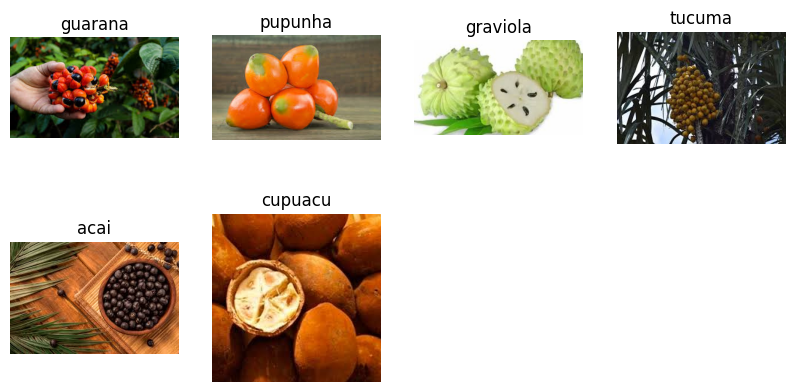

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/dataset/FruitinAmazon/train"

# Get class folders
classes = [cls for cls in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, cls))]

images = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_list = os.listdir(cls_path)

    if len(img_list) == 0:
        continue

    img_name = random.choice(img_list)
    img_path = os.path.join(cls_path, img_name)
    images.append((cls, img_path))

# Plot images
plt.figure(figsize=(10,5))

for i, (cls, img_path) in enumerate(images):
    plt.subplot(2, (len(images)//2)+1, i+1)

    try:
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
    except:
        print(f"Error loading {img_path}")

plt.show()

The dataset contains multiple fruit classes stored in separate directories. Each class represents a different type of fruit. The images vary in size, lighting conditions, and orientation, which makes the classification task more realistic and challenging.

Remove Corrupted Images

In [ ]:
from PIL import Image
import os

train_dir = "/content/dataset/FruitinAmazon/train"

corrupted_images = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)

    if not os.path.isdir(cls_path):
        continue

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()  # checks corruption
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

# Final message
if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"Total removed: {len(corrupted_images)}")

No Corrupted Images Found.


All images in the dataset were checked for corruption using PIL. No corrupted images were found, ensuring data quality for training.

Load Dataset using Keras



In [ ]:
train_dir = "/content/dataset/FruitinAmazon/train"

In [ ]:
# Create dataset FIRST
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# ✅ GET class names HERE (before map)
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

# Normalize AFTER
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


The dataset contains 6 classes of fruits. A total of 90 images were loaded, with 72 used for training and 18 for validation. The dataset was successfully processed and prepared for model training.

Build CNN Model

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Dense Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

A Convolutional Neural Network was implemented with two convolutional layers followed by max pooling layers. The extracted features were flattened and passed through fully connected dense layers. Finally, a softmax output layer was used for multi-class classification.

Compile + Train Model

1. Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

2. Add Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

3. Train Model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.2153 - loss: 2.2248

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 599ms/step - accuracy: 0.2083 - loss: 2.3965 - val_accuracy: 0.1667 - val_loss: 2.2728
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.1777 - loss: 1.8747

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.2361 - loss: 1.8530 - val_accuracy: 0.2778 - val_loss: 1.9739
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.4323 - loss: 1.6842

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 518ms/step - accuracy: 0.3750 - loss: 1.6749 - val_accuracy: 0.2778 - val_loss: 1.7834
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 812ms/step - accuracy: 0.4722 - loss: 1.4925 - val_accuracy: 0.1111 - val_loss: 1.9277
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.3883 - loss: 1.4837

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 456ms/step - accuracy: 0.4306 - loss: 1.4505 - val_accuracy: 0.2222 - val_loss: 1.7153
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.3860 - loss: 1.3165

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 489ms/step - accuracy: 0.3611 - loss: 1.3123 - val_accuracy: 0.1111 - val_loss: 1.7050
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 442ms/step - accuracy: 0.5972 - loss: 1.1644 - val_accuracy: 0.3333 - val_loss: 1.7642
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.6262 - loss: 1.0423

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 491ms/step - accuracy: 0.5972 - loss: 1.0491 - val_accuracy: 0.2778 - val_loss: 1.6185
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 433ms/step - accuracy: 0.7639 - loss: 0.8281 - val_accuracy: 0.2222 - val_loss: 1.6640
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.8397 - loss: 0.6619

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 478ms/step - accuracy: 0.8472 - loss: 0.6763 - val_accuracy: 0.1667 - val_loss: 1.5492
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 926ms/step - accuracy: 0.8611 - loss: 0.5508 - val_accuracy: 0.3889 - val_loss: 2.0274
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 848ms/step - accuracy: 0.8889 - loss: 0.4400 - val_accuracy: 0.3333 - val_loss: 2.1549
Epoch 13/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9294 - loss: 0.3234

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 582ms/step - accuracy: 0.9444 - loss: 0.3038 - val_accuracy: 0.3889 - val_loss: 1.4960
Epoch 14/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 433ms/step - accuracy: 0.9722 - loss: 0.2012 - val_accuracy: 0.5556 - val_loss: 1.5212
Epoch 15/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 440ms/step - accuracy: 1.0000 - loss: 0.1265 - val_accuracy: 0.4444 - val_loss: 1.8702
Epoch 16/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 451ms/step - accuracy: 0.9861 - loss: 0.1059 - val_accuracy: 0.3333 - val_loss: 1.8113
Epoch 17/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 447ms/step - accuracy: 0.9861 - loss: 0.0821 - val_accuracy: 0.3889 - val_loss: 1.9341
Epoch 18/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 1.0000 - loss: 0.0268 - val_accuracy: 0.3889 - val_loss: 2.3523
Epoch 19/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 454ms/step - accuracy: 1.0000 - loss: 0.0191 - val_accuracy: 0.3889 - val_loss: 2.3684
Epoch 20/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 716ms/step - accuracy: 1.0000 - loss: 0.0149 - val_accuracy: 0.5000 - val_loss: 2.2

The model was compiled using the Adam optimizer and sparse categorical crossentropy loss function. It was trained using the training dataset with validation data. EarlyStopping and ModelCheckpoint callbacks were used to prevent overfitting and save the best model.

Evaluate model

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.3889 - loss: 1.4960
Validation Accuracy: 0.3888888955116272


The model was evaluated on the validation dataset and achieved an accuracy of approximately 38.9%. The relatively lower validation accuracy compared to training accuracy indicates overfitting due to limited dataset size.

Save and Load Model

1. Save

In [ ]:
model.save("cnn_model.keras")

2. Load

In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("cnn_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Evaluate Loaded Model

In [ ]:
loss, acc = loaded_model.evaluate(val_ds)
print("Loaded Model Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.3889 - loss: 1.4960
Loaded Model Accuracy: 0.3888888955116272


The trained CNN model was successfully saved and reloaded using Keras. The loaded model achieved the same accuracy as the original model (~38.9%), confirming that the model was stored and restored correctly.

Predictions + Classification

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step
              precision    recall  f1-score   support

        acai       1.00      1.00      1.00         1
     cupuacu       0.25      0.50      0.33         2
    graviola       1.00      0.33      0.50         3
     guarana       0.57      0.80      0.67         5
     pupunha       0.00      0.00      0.00         4
      tucuma       0.00      0.00      0.00         3

    accuracy                           0.39        18
   macro avg       0.47      0.44      0.42        18
weighted avg       0.41      0.39      0.36        18



The classification report shows that the model performs well on some classes but poorly on others. This imbalance is due to the small dataset size and uneven distribution of samples across classes. Overall accuracy is approximately 39%, indicating the need for more data or regularization techniques.

Plot Training Graphs

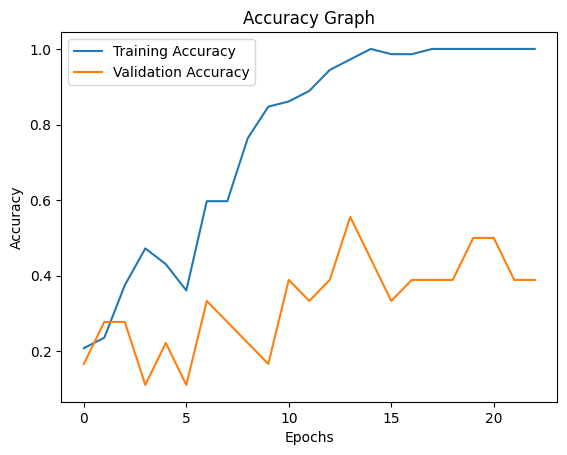

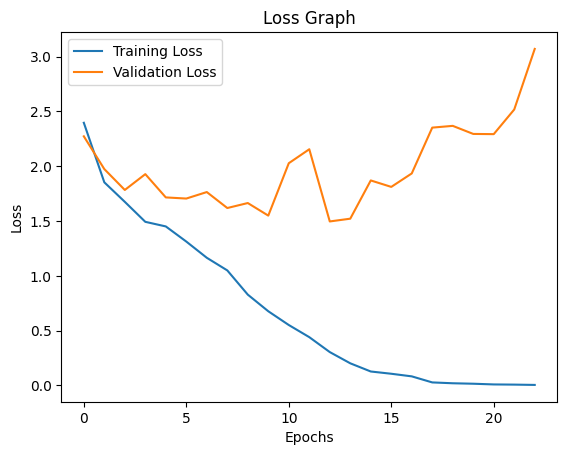

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

The training accuracy increases steadily and reaches close to 100%, while validation accuracy fluctuates and remains significantly lower. Similarly, training loss decreases while validation loss increases. This indicates that the model is overfitting the training data due to the small dataset size.